# Aesop AbstractGraph embedding and clustering

This notebook walks through the experiment in visible stages: loading the tales, building or reusing semantic graphs, converting those graphs to `AbstractGraph` objects, pooling graph features, building the text baseline, and clustering. The conversion cell prints the input/output graph types and sizes so the representation can be inspected before vectorization.

The Project Gutenberg edition is titled *Three Hundred Aesop's Fables* and contains 313 indexed tales. `SMOKE_TEST` and `SMOKE_LIMIT` control the sample size. Graph extraction and text embeddings use hosted APIs and may incur charges. Install with `pip install -e '.[dev,abstractgraph]'`. Generated data is stored under `data/processed/aesop_abstractgraph/`.


In [9]:
from pathlib import Path
import sys
from collections import Counter
import hashlib
import json
import pickle

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Markdown
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances

ROOT = Path.cwd()
if not (ROOT / "configs").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from semantic_graphicalizer import (
    DEFAULT_OPENAI_EMBEDDING_MODEL,
    DEFAULT_OPENAI_MODEL,
    OpenAIEmbeddingClient,
    SemanticGraphicalizer,
    load_aesop_fables,
    vectorize_abstract_graphs,
)
from semantic_graphicalizer.model import as_embedding_client
from experiments.aesop_graph_embeddings_clustering import (
    _cluster_representations,
    _corpus_metadata,
    _load_or_build_text_vectors,
)

SMOKE_TEST = True
SMOKE_LIMIT = 32
EMBED_NODES = True
EMBEDDING_MODEL = DEFAULT_OPENAI_EMBEDDING_MODEL
RANDOM_SEED = 17
NBITS = 14

cache_dir = ROOT / "data" / "processed" / "aesop_abstractgraph"
cache_dir.mkdir(parents=True, exist_ok=True)
stories = load_aesop_fables(
    limit=SMOKE_LIMIT if SMOKE_TEST else None,
    cache_dir=ROOT / "data" / "raw",
)
metadata, source_hashes, corpus_hash = _corpus_metadata(stories)
n_tales = len(stories)
print(f"Loaded {n_tales} tales; corpus SHA256: {corpus_hash}")


Loaded 32 tales; corpus SHA256: db047414f733d50588151ce4be5835555f6f16351fa03658445825c7d20f7120


## 1. Build or load the canonical semantic graphs

Each cached object here should be a NetworkX `MultiDiGraph`. On a cache miss, `SemanticGraphicalizer.transform([story])[0]` runs the extraction pipeline for that story and returns the canonical graph. The configuration hash keeps caches separate when the ontology or prompts change.


In [10]:
config_paths = {
    "ontology": ROOT / "configs" / "ontologies" / "aesop.yaml",
    "prompts": ROOT / "configs" / "prompts" / "aesop.yaml",
}
config_hashes = {
    name: hashlib.sha256(path.read_bytes()).hexdigest()
    for name, path in config_paths.items()
}
graph_config_hash = hashlib.sha256(json.dumps({
    "extraction_model": DEFAULT_OPENAI_MODEL,
    "config_sha256": config_hashes,
}, sort_keys=True).encode("utf-8")).hexdigest()

graphicalizer = SemanticGraphicalizer(
    ontology=config_paths["ontology"],
    prompts=config_paths["prompts"],
    embedding_model=EMBEDDING_MODEL,
)

graphs = []
for index, (story, row) in enumerate(zip(stories, metadata), start=1):
    checkpoint = cache_dir / f"{row['tale_id']}-{graph_config_hash[:8]}.graph.pkl"
    if checkpoint.exists():
        with checkpoint.open("rb") as handle:
            graph = pickle.load(handle)
        source = "cache"
    else:
        graph = graphicalizer.transform([story])[0]
        with checkpoint.open("wb") as handle:
            pickle.dump(graph, handle)
        source = "extracted"
    graphs.append(graph)
    print(
        f"{index:>3}/{len(stories)} {row['title']}: {source}; "
        f"{type(graph).__name__}, directed={graph.is_directed()}, "
        f"multigraph={graph.is_multigraph()}, nodes={graph.number_of_nodes()}, "
        f"edges={graph.number_of_edges()}"
    )


  1/32 The Lion And The Mouse: cache; MultiDiGraph, directed=True, multigraph=True, nodes=18, edges=26
  2/32 The Wolf And The Lamb: cache; MultiDiGraph, directed=True, multigraph=True, nodes=34, edges=32
  3/32 The Ass And The Grasshopper: cache; MultiDiGraph, directed=True, multigraph=True, nodes=16, edges=14
  4/32 The Wolf and the Crane: cache; MultiDiGraph, directed=True, multigraph=True, nodes=18, edges=18
  5/32 The Father And His Sons: cache; MultiDiGraph, directed=True, multigraph=True, nodes=23, edges=26
  6/32 The Bat And The Weasels: cache; MultiDiGraph, directed=True, multigraph=True, nodes=29, edges=28
  7/32 The Cock and the Jewel: cache; MultiDiGraph, directed=True, multigraph=True, nodes=14, edges=10
  8/32 The Swallow and the Crow: cache; MultiDiGraph, directed=True, multigraph=True, nodes=13, edges=10
  9/32 The Kingdom of the Lion: cache; MultiDiGraph, directed=True, multigraph=True, nodes=18, edges=16
 10/32 The Traveler and His Dog: cache; MultiDiGraph, directed=T

## 2. Convert semantic graphs to `AbstractGraph` objects

The semantic graph is a directed multigraph because relation arguments can create parallel edges. `to_abstract_graphs` converts each one into an `AbstractGraph` with a simple directed base graph. With `parallel_edge_policy="combine"`, parallel semantic edges are represented together in the base edge's `semantic_edges` metadata. Node embeddings are optionally copied to the base nodes' numeric `attribute` vectors.

Each AbstractGraph also has an interpretation graph. The next cell prints both graph sizes and checks how many semantic edges were combined.


In [11]:
abstract_settings = {
    "embedding_key": "embedding",
    "interpretation_mode": "per_entity",
    "chunk_key": "chunk_id",
    "parallel_edge_policy": "combine",
    "preserve_direction": True,
    "nbits": NBITS,
}

# This call may compute embeddings for semantic nodes first, then converts each
# MultiDiGraph to an AbstractGraph. The returned objects are already converted;
# they must not be passed back into a transformer that wraps raw NetworkX graphs.
abstract_graphs = graphicalizer.to_abstract_graphs(
    graphs,
    embed_nodes=EMBED_NODES,
    **abstract_settings,
)

conversion_rows = []
for row, semantic_graph, abstract_graph in zip(metadata, graphs, abstract_graphs):
    base = abstract_graph.base_graph
    combined_edge_count = sum(
        max(0, len(data.get("semantic_edges", [])) - 1)
        for _source, _target, data in base.edges(data=True)
    )
    embedded_nodes = sum("attribute" in data for _node, data in base.nodes(data=True))
    conversion_rows.append({
        "tale": row["title"],
        "input_type": type(semantic_graph).__name__,
        "input_nodes": semantic_graph.number_of_nodes(),
        "input_edges": semantic_graph.number_of_edges(),
        "base_type": type(base).__name__,
        "base_directed": base.is_directed(),
        "base_multigraph": base.is_multigraph(),
        "base_nodes": base.number_of_nodes(),
        "base_edges": base.number_of_edges(),
        "combined_parallel_edges": combined_edge_count,
        "interpretation_nodes": abstract_graph.interpretation_graph.number_of_nodes(),
        "nodes_with_numeric_attributes": embedded_nodes,
    })

try:
    import pandas as pd
    display(pd.DataFrame(conversion_rows))
except ImportError:
    display(conversion_rows)

# Show a small before/after sample. A combined base edge retains all of its
# source semantic edges (including their original role and direction).
sample_index = 0
semantic_sample = graphs[sample_index]
abstract_sample = abstract_graphs[sample_index]
print(f"\nConversion sample: {metadata[sample_index]['title']}")
print("Semantic nodes:")
for node_id, data in list(semantic_sample.nodes(data=True))[:5]:
    print(f"  {node_id!r}: type={data.get('type')!r}, relation={data.get('relation')!r}")
print("Abstract base nodes:")
for node_id, data in list(abstract_sample.base_graph.nodes(data=True))[:5]:
    attribute = data.get("attribute")
    attribute_shape = None if attribute is None else np.asarray(attribute).shape
    print(f"  {node_id!r}: label={data.get('label')!r}, attribute_shape={attribute_shape}")
print("Semantic edges:")
for source, target, key, data in list(semantic_sample.edges(keys=True, data=True))[:5]:
    print(f"  {source!r} -> {target!r} [{key!r}]: role={data.get('role')!r}")
print("Abstract base edges:")
for source, target, data in list(abstract_sample.base_graph.edges(data=True))[:5]:
    print(f"  {source!r} -> {target!r}: label={data.get('label')!r}; ")
    for semantic_edge in data.get("semantic_edges", []):
        print(f"      source={semantic_edge.get('source')!r}, target={semantic_edge.get('target')!r}, role={semantic_edge.get('role')!r}")


,tale,input_type,input_nodes,input_edges,base_type,base_directed,base_multigraph,base_nodes,base_edges,combined_parallel_edges,interpretation_nodes,nodes_with_numeric_attributes
0,The Lion And The Mouse,MultiDiGraph,18,26,DiGraph,True,False,18,26,0,18,18
1,The Wolf And The Lamb,MultiDiGraph,34,32,DiGraph,True,False,34,32,0,34,34
2,The Ass And The Grasshopper,MultiDiGraph,16,14,DiGraph,True,False,16,14,0,16,16
3,The Wolf and the Crane,MultiDiGraph,18,18,DiGraph,True,False,18,18,0,18,18
4,The Father And His Sons,MultiDiGraph,23,26,DiGraph,True,False,23,21,5,23,23
5,The Bat And The Weasels,MultiDiGraph,29,28,DiGraph,True,False,29,28,0,29,29
6,The Cock and the Jewel,MultiDiGraph,14,10,DiGraph,True,False,14,10,0,14,14
7,The Swallow and the Crow,MultiDiGraph,13,10,DiGraph,True,False,13,10,0,13,13
8,The Kingdom of the Lion,MultiDiGraph,18,16,DiGraph,True,False,18,16,0,18,18
9,The Traveler and His Dog,MultiDiGraph,20,20,DiGraph,True,False,20,20,0,20,20



Conversion sample: The Lion And The Mouse
Semantic nodes:
  'animal::lion': type='Animal', relation=None
  'animal::mouse': type='Animal', relation=None
  'trait::mercy': type='Trait', relation=None
  'object::strong_ropes': type='Object', relation=None
  'moral::kindness_repaid': type='Moral', relation=None
Abstract base nodes:
  'animal::lion': label='', attribute_shape=(1536,)
  'animal::mouse': label='', attribute_shape=(1536,)
  'trait::mercy': label='', attribute_shape=(1536,)
  'object::strong_ropes': label='', attribute_shape=(1536,)
  'moral::kindness_repaid': label='', attribute_shape=(1536,)
Semantic edges:
  'document-fbdceb1ca5cd:chunk-0:relation:r1' -> 'animal::mouse' ['argument:document-fbdceb1ca5cd:chunk-0:relation:r1:0']: role='performer'
  'document-fbdceb1ca5cd:chunk-0:relation:r1' -> 'document-fbdceb1ca5cd:chunk-0:relation:r1' ['argument:document-fbdceb1ca5cd:chunk-0:relation:r1:1']: role='action'
  'document-fbdceb1ca5cd:chunk-0:relation:r2' -> 'animal::lion' ['ar

## 3. Vectorize each tale with `AbstractGraphTransformer`

The transformer takes NetworkX graphs and creates its own `AbstractGraph`. This installed and current upstream implementation does not accept an already-created `AbstractGraph` as its input. The tested adapter therefore passes each converted object's simple `base_graph` and rebuilds the per-entity interpretation mapping during decomposition.

Before vectorization, inspect `to_array()` on a converted object to see the node-level feature matrix. `AbstractGraphTransformer` applies `vectorize()`, which sets feature columns 0 and 1 to bias and base-node degree, then sums node rows into one sparse vector per tale. The helper below uses that transformer path.


In [12]:
example_abstract_graph = abstract_graphs[0]
node_feature_matrix = example_abstract_graph.to_array()
print(f"Example tale: {metadata[0]['title']}")
print(f"Base nodes: {example_abstract_graph.base_graph.number_of_nodes()}")
print(f"Node feature matrix before graph pooling: {node_feature_matrix.shape}")

graph_inputs = [abstract_graph.base_graph for abstract_graph in abstract_graphs]
print("Transformer input types:", sorted({type(graph).__name__ for graph in graph_inputs}))
print("First transformer input is simple:", not graph_inputs[0].is_multigraph())

graph_matrix = vectorize_abstract_graphs(abstract_graphs, nbits=NBITS)
print(f"Graph-level matrix: {graph_matrix.shape}; format={graph_matrix.format}; nnz={graph_matrix.nnz}")

# Save node embeddings added during AbstractGraph conversion to the graph cache.
for graph, row in zip(graphs, metadata):
    checkpoint = cache_dir / f"{row['tale_id']}-{graph_config_hash[:8]}.graph.pkl"
    with checkpoint.open("wb") as handle:
        pickle.dump(graph, handle)


Example tale: The Lion And The Mouse
Base nodes: 18
Node feature matrix before graph pooling: (18, 25165824)
Transformer input types: ['DiGraph']
First input is simple: True
Graph-level matrix: (32, 25165824); format=csr; nnz=293438


## 4. Build the direct-text baseline and cluster both representations

This last stage uses the same cached text-embedding and clustering routines as the experiment module. Graph conversion and pooling above are now fully visible in this notebook.


In [13]:
raw_embedder = graphicalizer.embedder or OpenAIEmbeddingClient(model=EMBEDDING_MODEL)
embedding_client = as_embedding_client(raw_embedder)
text_matrix = _load_or_build_text_vectors(
    stories,
    source_hashes,
    embedding_client,
    cache_dir / "direct_text_vectors.pkl",
    EMBEDDING_MODEL,
)

clustering = _cluster_representations(graph_matrix, text_matrix, RANDOM_SEED)
graph_features = clustering["graph_features"]
text_features = clustering["text_features"]
cluster_results = clustering["cluster_results"]
metric_rows = clustering["metric_rows"]
agreement_rows = clustering["agreement_rows"]
max_k = clustering["max_k"]
print(f"Tales: {n_tales} | graph vectors: {graph_matrix.shape} | text vectors: {text_matrix.shape}")
print(f"Graph reduction components: {clustering['svd_components']}")


Tales: 32 | graph vectors: (32, 25165824) | text vectors: (32, 1536)
Graph reduction components: 31


## What the experiment computes

Each tale gets two representations. In the graph path, the pipeline segments the story, summarizes and normalizes each chunk, decomposes it into assertions, extracts entities and relations, then tries to add higher-order relations in the resolve stage. It optionally embeds graph nodes, converts the semantic graph to an `AbstractGraph`, and sums the node feature rows into one sparse vector per tale. Because this is a sum, graph size and repeated features can affect vector magnitude. The text baseline splits each tale into chunks of up to 6,000 characters, embeds each chunk, and averages the chunk vectors.

Extraction and resolution use the same reference validation and retry mechanism. The model gets feedback when an argument points to an unknown ID. If invalid references remain after retries, those relations and any relations depending on them are omitted. If a stage keeps returning structurally invalid output or fails, that extraction chunk or optional resolve stage is skipped so processing can continue.

Before clustering, the sparse graph vectors are scaled without centering and reduced with TruncatedSVD to at most 50 components. The text vectors are standardized in their original embedding space. KMeans and agglomerative clustering are each run for `k = 2` through `min(8, tales - 1)` on both representations.


## Compare clusterings

Metric scores are inspection aids, not proof of semantic quality. Compare representative tales and boundary cases before drawing conclusions.


In [14]:
try:
    import pandas as pd
    metrics = pd.DataFrame(metric_rows).sort_values(
        ["representation", "silhouette"], ascending=[True, False]
    )
    display(metrics)
except ImportError:
    display(metric_rows)

for row in agreement_rows:
    print(f"k={row['k']}: ARI={row['ari']:.3f}, NMI={row['nmi']:.3f}")


,representation,algorithm,k,silhouette,calinski_harabasz,davies_bouldin
0,AbstractGraph,kmeans,2,0.492547,6.636591,0.360428
7,AbstractGraph,agglomerative,2,0.492547,6.636591,0.360428
1,AbstractGraph,kmeans,3,0.273133,4.877385,0.492577
8,AbstractGraph,agglomerative,3,0.259712,5.080003,1.146216
9,AbstractGraph,agglomerative,4,0.259466,4.586870,0.983902
2,AbstractGraph,kmeans,4,0.247211,4.283793,0.514336
11,AbstractGraph,agglomerative,6,0.126922,4.148495,1.029020
10,AbstractGraph,agglomerative,5,0.120424,4.272526,1.327815
4,AbstractGraph,kmeans,6,0.115616,3.574105,1.008467
3,AbstractGraph,kmeans,5,0.115510,3.495322,0.604336


k=2: ARI=0.000, NMI=0.053
k=3: ARI=-0.026, NMI=0.079
k=4: ARI=-0.041, NMI=0.106
k=5: ARI=-0.049, NMI=0.162
k=6: ARI=-0.072, NMI=0.205
k=7: ARI=-0.060, NMI=0.230
k=8: ARI=-0.073, NMI=0.262


## How to read the scores

- **Silhouette** ranges from −1 to 1; higher means points are closer to their own cluster than to neighboring clusters. Values near 0 suggest overlap, and negative values can indicate poor assignments.
- **Calinski–Harabasz** compares between-cluster spread with within-cluster spread; higher is generally better.
- **Davies–Bouldin** measures how similar clusters are to their nearest neighboring cluster; lower is generally better.

Use these scores to compare choices within the same representation. Graph and text vectors live in different feature spaces, so their score magnitudes are not directly comparable. The ARI and NMI lines compare the *assignments* from graph and text KMeans at the same `k`: ARI is 1 for identical partitions and about 0 for chance-level agreement; NMI ranges from 0 (no shared information) to 1 (identical partitions). Agreement does not establish that either clustering is correct.


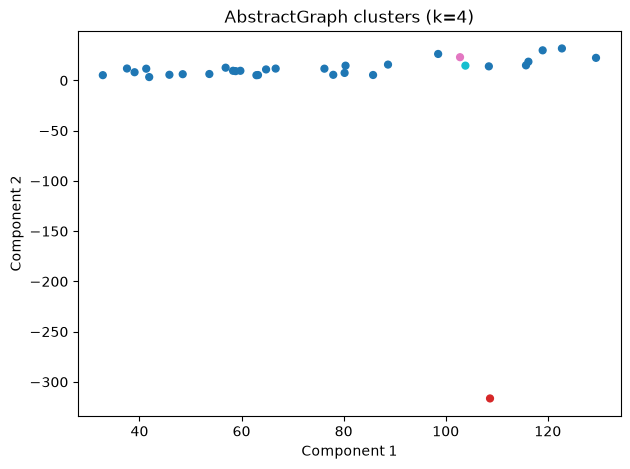

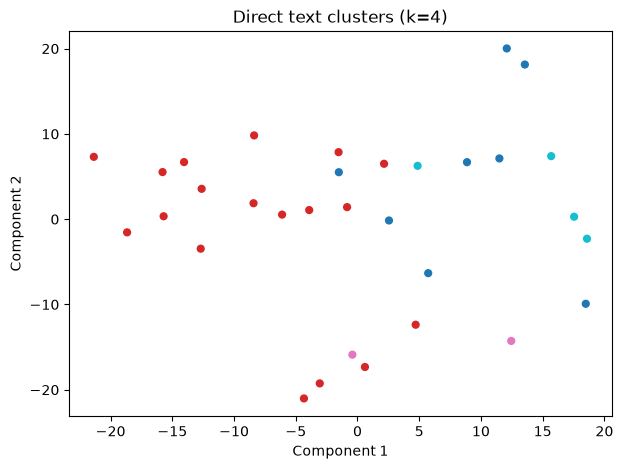

### Cluster 0 (29 tales) — representative: The Bear and the Fox


The Wolf And The Lamb (aesop-0001-a72355949ffb)
The Wolf And The Lamb


WOLF, meeting with a Lamb astray from the fold, resolved not to lay
violent hands on him, but to find some plea to justify to the Lamb the
Wolf’s right to eat him. He thus addressed him: “Sirrah, last year you
grossly insulted me.” “Indeed,” bleated the Lamb in a mournful tone of
voice, “I was not then born.” Then said the Wolf, “You feed in my
pasture.” “No, good sir,” replied the Lamb, “I have not yet tasted
grass.” Again said the Wolf, “You drink of my well.” “No,” exclaimed
the Lamb, “I never yet drank water, for as yet my mother’s milk is both
food and drink to me.” Upon which the Wolf seized him and ate him up,
saying, “Well! I won’t remain supperless, even though you refute every
one of my imputations.” The tyrant will always find a pretext for his
tyranny.

The Ass And The Grasshopper (aesop-0002-932912a3e124)
The Ass And The Grasshopper


AN ASS having heard some Grasshoppers chirping, was highly enchante

### Cluster 1 (1 tales) — representative: The Lion And The Mouse


The Lion And The Mouse (aesop-0000-fbdceb1ca5cd)
The Lion And The Mouse


A LION was awakened from sleep by a Mouse running over his face. Rising
up angrily, he caught him and was about to kill him, when the Mouse
piteously entreated, saying: “If you would only spare my life, I would
be sure to repay your kindness.” The Lion laughed and let him go. It
happened shortly after this that the Lion was caught by some hunters,
who bound him by strong ropes to the ground. The Mouse, recognizing his
roar, came and gnawed the rope with his teeth, and set him free,
exclaiming:

“You ridiculed the idea of my ever being able to help you, not
expecting to receive from me any repayment of your favour; now you know
that it is possible for even a Mouse to confer benefits on a Lion.”

Representative graph summary:
Entity types: [('Action', 10), ('Animal', 2), ('Trait', 2), ('Moral', 2), ('Object', 1), ('Character', 1)]
Relations: [('performs', 7), ('wants', 1), ('has_trait', 1), ('located_in', 1), ('in

### Cluster 2 (1 tales) — representative: The Herdsman and the Lost Bull


The Herdsman and the Lost Bull (aesop-0018-edfea1cb91c6)
The Herdsman and the Lost Bull


A HERDSMAN tending his flock in a forest lost a Bull-calf from the
fold. After a long and fruitless search, he made a vow that, if he
could only discover the thief who had stolen the Calf, he would offer a
lamb in sacrifice to Hermes, Pan, and the Guardian Deities of the
forest. Not long afterwards, as he ascended a small hillock, he saw at
its foot a Lion feeding on the Calf. Terrified at the sight, he lifted
his eyes and his hands to heaven, and said: “Just now I vowed to offer
a lamb to the Guardian Deities of the forest if I could only find out
who had robbed me; but now that I have discovered the thief, I would
willingly add a full-grown Bull to the Calf I have lost, if I may only
secure my own escape from him in safety.”

Representative graph summary:
Entity types: [('Action', 20), ('Animal', 4), ('Human', 2), ('Moral', 2), ('Place', 1), ('Trait', 1)]
Relations: [('performs', 9), ('has_trai

### Cluster 3 (1 tales) — representative: The Raven and the Swan


The Raven and the Swan (aesop-0031-5e544ac33f2c)
The Raven and the Swan


A RAVEN saw a Swan and desired to secure for himself the same beautiful
plumage. Supposing that the Swan’s splendid white color arose from his
washing in the water in which he swam, the Raven left the altars in the
neighborhood where he picked up his living, and took up residence in
the lakes and pools. But cleansing his feathers as often as he would,
he could not change their color, while through want of food he
perished.

Change of habit cannot alter Nature.

Representative graph summary:
Entity types: [('Animal', 8), ('Action', 6), ('Trait', 4), ('Place', 2), ('Moral', 2), ('Object', 1)]
Relations: [('performs', 2), ('located_in', 2), ('causes', 2), ('after', 2), ('interacts_with', 1), ('wants', 1)]
Argument roles: [('subject', 3), ('performer', 2), ('action', 2), ('place', 2), ('cause', 2), ('effect', 2)]


In [15]:
from textwrap import wrap

def print_wrapped_story(text, width=80):
    for paragraph in text.splitlines():
        wrapped = wrap(paragraph, width=width)
        print("\n".join(wrapped))

selected_k = min(4, n_tales - 1)
for representation, features, reducer in (
    ("AbstractGraph", graph_features, None),
    ("Direct text", text_features, PCA(n_components=2, random_state=RANDOM_SEED)),
):
    coordinates = reducer.fit_transform(features) if reducer is not None else features[:, :2]
    labels = cluster_results[(representation, "kmeans", selected_k)]
    plt.figure(figsize=(7, 5))
    plt.scatter(coordinates[:, 0], coordinates[:, 1], c=labels, cmap="tab10", s=24)
    plt.title(f"{representation} clusters (k={selected_k})")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.show()

labels = cluster_results[("AbstractGraph", "kmeans", selected_k)]
for label in sorted(set(labels)):
    members = np.flatnonzero(labels == label)
    distances = pairwise_distances(graph_features[members], metric="euclidean")
    medoid_index = members[int(np.argmin(distances.mean(axis=1)))]
    display(Markdown(
        f"### Cluster {label} ({len(members)} tales) — "
        f"representative: {metadata[medoid_index]['title']}"
    ))
    for member_index in members:
        row = metadata[member_index]
        print(f"\n{row['title']} ({row['tale_id']})")
        print_wrapped_story(stories[member_index], width=80)
    graph = graphs[medoid_index]
    entity_types = Counter(data.get("type") for _node, data in graph.nodes(data=True))
    relation_names = Counter(
        data.get("relation") for _node, data in graph.nodes(data=True)
        if data.get("relation")
    )
    argument_roles = Counter(
        data.get("role") for _source, _target, data in graph.edges(data=True)
    )
    print("\nRepresentative graph summary:")
    print("Entity types:", entity_types.most_common(6))
    print("Relations:", relation_names.most_common(6))
    print("Argument roles:", argument_roles.most_common(6))


## How to read the plots and tale examples

Colors show KMeans assignments for `selected_k`. Graph coordinates are the first two SVD features; text coordinates come from PCA. The axes have no direct semantic meaning, and positions should only be interpreted within each plot.

For each graph cluster, the notebook prints every member tale. The listed representative is the **medoid**: the tale with the lowest average Euclidean distance to the other members in the reduced graph feature space. Its entity-type, relation, and argument-role counts give a quick structural profile of that representative; they are not cluster-wide totals.

These are exploratory, unsupervised results. Extraction or resolution fallbacks can leave some graphs with fewer relations; embedding choices, corpus size, and feature scaling can also change the clusters. Read the tales and inspect borderline cases before treating a pattern as meaningful.


Inspect excerpts, recurring entity types, relations, argument roles, nearest tales, and boundary cases. Cached graph artifacts are stored under `data/processed/aesop_abstractgraph/` and are keyed by tale content and extraction configuration.
